# TreeCorr Stack Results

This notebook plots the TreeCorr stack outputs, preferring the leave-one-patch-out jackknife mean and jackknife errors when those arrays are present in the stack files.

For legacy `fcolors` files that still store flux-color ratios, the plotted values are converted with

$$c = -2.5 \log_{10}(f_1/f_2), \qquad \sigma_c = \frac{2.5}{\ln 10}\frac{\sigma_f}{f}.$$

Both axes are log-scaled, so non-positive plotted values are omitted.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

COLORS = ("g-i",)  # ("g-r", "r-i", "i-z", "g-i")
STACK_NAME = "treecorr"
PLOT_JACKKNIFE_SAMPLES = True
JACKKNIFE_SAMPLE_ALPHA = 0.18


def stack_roots(stack_name=STACK_NAME):
    return [
        Path("../results/stacks") / stack_name,
        Path("results/stacks") / stack_name,
    ]


def find_stack_dir(stack_name=STACK_NAME):
    for path in stack_roots():
        if path.exists():
            return path

    if stack_name == "treecorr":
        matches = []
        for path in stack_roots():
            matches.extend(path.parent.glob("treecorr*"))
        matches = [path for path in matches if path.is_dir()]
        if matches:
            return max(matches, key=lambda path: path.stat().st_mtime)

    raise FileNotFoundError(f"Could not find results/stacks/{stack_name}")


def load_stack(kind):
    path = stack_dir / f"stack_{kind}.npz"
    if not path.exists():
        raise FileNotFoundError(path)
    return np.load(path)


stack_dir = find_stack_dir()
stack_dir

PosixPath('../results/stacks/treecorr')

In [2]:
def color_style(color):
    return {
        "g-r": "C0",
        "r-i": "C2",
        "i-z": "C3",
        "g-i": "k",
    }[color]


def fcolor_to_mag(fcolor, fcolor_err):
    fcolor = np.asarray(fcolor, dtype=float)
    fcolor_err = np.asarray(fcolor_err, dtype=float)

    mag = np.full_like(fcolor, np.nan)
    mag_err = np.full_like(fcolor_err, np.nan)
    good = np.isfinite(fcolor) & np.isfinite(fcolor_err) & (fcolor > 0)

    mag[good] = -2.5 * np.log10(fcolor[good])
    mag_err[good] = 2.5 / np.log(10) * fcolor_err[good] / fcolor[good]
    return mag, mag_err


def covariance_err(data, color):
    cov_key = f"{color}_cov"
    if cov_key not in data.files:
        return None
    cov = np.asarray(data[cov_key], dtype=float)
    return np.sqrt(np.clip(np.diag(cov), 0, None))


def profile(data, color, kind):
    r = data[f"{color}_bin_centers"]

    if f"{color}_jackknife_avg" in data.files:
        y = data[f"{color}_jackknife_avg"]
        yerr = data[f"{color}_jackknife_err"]
        source = "jackknife mean"
    else:
        y = data[f"{color}_avg"]
        yerr = covariance_err(data, color)
        if yerr is None:
            yerr = data[f"{color}_err"]
        source = "full-sample mean with jackknife errors"

    legacy_flux_ratio = (
        kind == "fcolors" and f"{color}_forward_raw_avg" not in data.files
    )
    if legacy_flux_ratio:
        y, yerr = fcolor_to_mag(y, yerr)

    return r, y, yerr, source


def jackknife_samples(data, color):
    key = f"{color}_jackknife_samples"
    if key not in data.files:
        return None
    samples = np.asarray(data[key], dtype=float)
    if samples.ndim != 2:
        return None
    return samples


def plot_jackknife_samples(data, color, r, ax):
    samples = jackknife_samples(data, color)
    if samples is None:
        return

    for sample in samples:
        show = np.isfinite(r) & np.isfinite(sample) & (r > 0) & (sample > 0)
        if not np.any(show):
            continue
        ax.plot(
            r[show],
            sample[show],
            marker=".",
            markersize=3,
            lw=0.7,
            alpha=JACKKNIFE_SAMPLE_ALPHA,
            color=color_style(color),
            zorder=1,
        )


def plot_profiles(data, kind, ax):
    sources = []
    for color in COLORS:
        if f"{color}_avg" not in data.files:
            continue

        r, y, yerr, source = profile(data, color, kind)
        sources.append(source)
        if PLOT_JACKKNIFE_SAMPLES:
            plot_jackknife_samples(data, color, r, ax)

        show = (
            np.isfinite(r)
            & np.isfinite(y)
            & np.isfinite(yerr)
            & (r > 0)
            & (y > 0)
            & (yerr >= 0)
        )
        if not np.any(show):
            print(f"{kind} {color}: no positive values to show on log y-axis")
            continue

        ax.errorbar(
            r[show],
            y[show],
            yerr=yerr[show],
            marker="o",
            capsize=2,
            lw=1,
            label=color,
            color=color_style(color),
            zorder=10,
        )

    source_label = ", ".join(sorted(set(sources)))
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$r_\perp$ [Mpc]")
    ax.set_ylabel("Magnitude color")
    ax.set_title(f"{kind}: {source_label}")
    ax.legend(frameon=False)

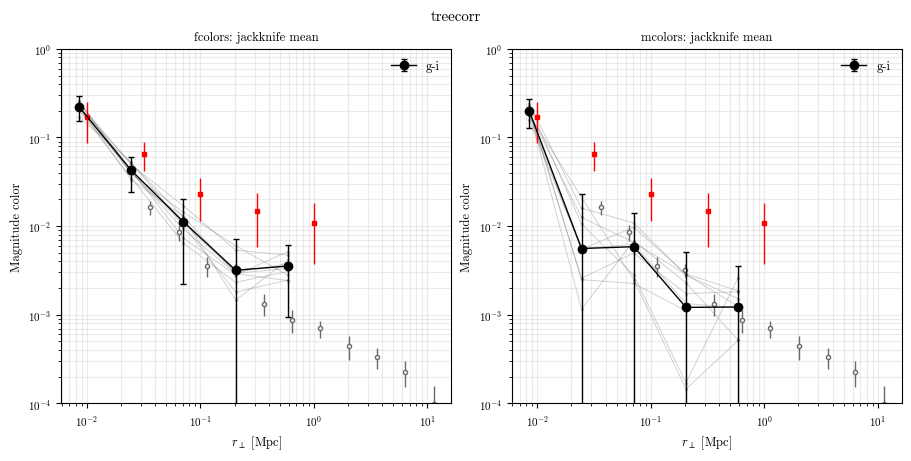

In [5]:
fcolors = load_stack("fcolors")
mcolors = load_stack("mcolors")

# Points from papers to compare
x_mean = np.array([0.01, 0.03162278, 0.1, 0.31622777, 1.0])
y_mean = np.array([0.16964638, 0.0659737, 0.02304866, 0.0147042, 0.01094266])
y_err = np.array([0.08262554, 0.0238592, 0.01168919, 0.00885627, 0.0071977])

menard_x = np.array(
    [
        0.03602872,
        0.06428023,
        0.11318573,
        0.20193903,
        0.3602872,
        0.63439992,
        1.13185734,
        2.0193903,
        3.60287203,
        6.34399924,
        11.31857345,
    ]
)
menard_y = np.array(
    [
        1.63789371e-02,
        8.59143946e-03,
        3.54364779e-03,
        3.20253958e-03,
        1.33774589e-03,
        8.70082512e-04,
        7.01703829e-04,
        4.44991431e-04,
        3.32642719e-04,
        2.27584593e-04,
        9.87428128e-05,
    ]
)
menard_err = np.array(
    [
        2.92804022e-03,
        1.79540233e-03,
        9.06266528e-04,
        5.25054143e-04,
        3.63508387e-04,
        2.50517311e-04,
        1.57440117e-04,
        1.35420409e-04,
        8.50713672e-05,
        7.30382507e-05,
        5.69640277e-05,
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), constrained_layout=True)
plot_profiles(fcolors, "fcolors", axes[0])
plot_profiles(mcolors, "mcolors", axes[1])

for ax in axes:
    ax.grid(True, which="both", alpha=0.25)
    ax.set(
        xticks=[1e-2, 1e-1, 1e0, 1e1],
        yticks=[1e-4, 1e-3, 1e-2, 1e-1, 1e0],
        ylim=(1e-4, 1e0),
    )
    ax.errorbar(
        menard_x,
        menard_y,
        yerr=menard_err,
        c="dimgray",
        mfc="w",
        ls="",
        marker=".",
        label="Menard 2010",
    )
    ax.errorbar(
        x_mean,
        y_mean,
        yerr=y_err,
        color="r",
        label="Rubin DP1",
        ls="",
        marker="s",
        markersize=3,
    )

fig.suptitle(stack_dir.name)
plt.show()

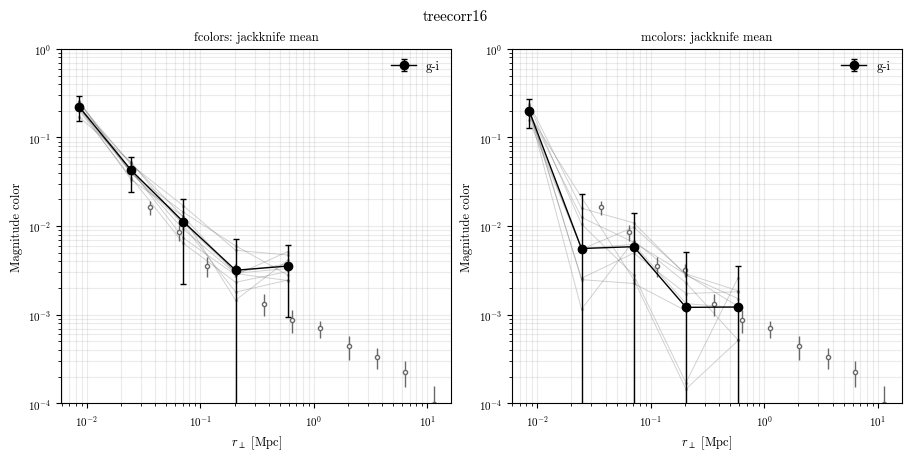

In [21]:
from astropy.cosmology import Planck18
import astropy.units as u


def arcmin_per_Mpc(z):
    D_A = Planck18.angular_diameter_distance(z).to(u.Mpc).value
    return (180 * 60) / (np.pi * D_A)


# Digitization of Menard Fig. 6
menard = np.array(
    [
        0.08101611782270254,
        0.16378937069540647,
        0.1445439770745927,
        0.08591439458053093,
        0.25451552912158953,
        0.035436477855785485,
        0.45409096109724745,
        0.03202539577230472,
        0.8101611782270257,
        0.01337745893148901,
        1.4265457829751846,
        0.008700825116137813,
        2.545155291215897,
        0.007017038286703837,
        4.540909610972479,
        0.004449914313113396,
        8.101611782270266,
        0.003326427190621989,
        14.26545782975184,
        0.002275845926074791,
        25.45155291215894,
        0.0009874281281804155,
        0.08101611782270263,
        0.19306977288832497,
        0.14454397707459266,
        0.10386841787287614,
        0.2545155291215898,
        0.044499143131133935,
        0.45409096109724756,
        0.0372759372031494,
        0.810161178227026,
        0.01701254279852591,
        1.4454397707459266,
        0.011205998227840196,
        2.545155291215897,
        0.008591439458053098,
        4.540909610972477,
        0.005804118407660814,
        7.995712002123401,
        0.004177140862395749,
        14.265457829751824,
        0.0030062284327739,
        25.45155291215894,
        0.0015570684047537333,
    ]
)
menard = menard.reshape(-1, 2)

menard_x = menard[:11, 0] / arcmin_per_Mpc(3.6)
menard_y = menard[:11, 1]
menard_err = menard[11:, 1] - menard_y

# Above was digitized from incorrect y-axis. Need to divide by 10
menard_y /= 10
menard_err /= 10

In [ ]:
# Points from papers to compare
y_mean = np.array([0.16964638, 0.0659737, 0.02304866, 0.0147042, 0.01094266])
y_err = np.array([0.08262554, 0.0238592, 0.01168919, 0.00885627, 0.0071977])

menard_x = np.array(
    [
        0.03602872,
        0.06428023,
        0.11318573,
        0.20193903,
        0.3602872,
        0.63439992,
        1.13185734,
        2.0193903,
        3.60287203,
        6.34399924,
        11.31857345,
    ]
)
menard_y = np.array(
    [
        1.63789371e-02,
        8.59143946e-03,
        3.54364779e-03,
        3.20253958e-03,
        1.33774589e-03,
        8.70082512e-04,
        7.01703829e-04,
        4.44991431e-04,
        3.32642719e-04,
        2.27584593e-04,
        9.87428128e-05,
    ]
)
menard_err = np.array(
    [
        2.92804022e-03,
        1.79540233e-03,
        9.06266528e-04,
        5.25054143e-04,
        3.63508387e-04,
        2.50517311e-04,
        1.57440117e-04,
        1.35420409e-04,
        8.50713672e-05,
        7.30382507e-05,
        5.69640277e-05,
    ]
)

In [29]:
menard_err

array([2.92804022e-03, 1.79540233e-03, 9.06266528e-04, 5.25054143e-04,
       3.63508387e-04, 2.50517311e-04, 1.57440117e-04, 1.35420409e-04,
       8.50713672e-05, 7.30382507e-05, 5.69640277e-05])